In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle




In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\dataset\test_set_acute_oral_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
         CASRN          DTXSID  \
0   98119-87-0  DTXSID20243457   
1    1504-74-1             nan   
2     303-45-7   DTXSID5023110   
3  173159-57-4   DTXSID7034753   
4     100-53-8   DTXSID6026664   

                                                Name     Structure_Source  \
0  Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...           EPA_DSSTox   
1                                                     Public_CrossChecked   
2                                           Gossypol           EPA_DSSTox   
3                                      Foramsulfuron           EPA_DSSTox   
4                                Benzenemethanethiol           EPA_DSSTox   

                                     Canonical_QSARr Salt_Solvent  \
0  OC(=O)C1=CC=CC=C1NC(=O)C(=CC1C=CC=CC=1)C(=O)NC...            ?   
1                                COC1C=CC=CC=1C=CC=O            ?   
2  CC1C=C2C(C(C=O)=C(O)C(O)=C2C(C)C)=C(O)C=1C1=C(...            ?   
3  CN(C)C(=O)C1C=CC(=CC=1S(=O)(=O)NC(=O)

In [3]:
test_df

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,98119-87-0,DTXSID20243457,"Benzoic acid, 2,2'-((1,3-dioxo-2-(phenylmethyl...",EPA_DSSTox,OC(=O)C1=CC=CC=C1NC(=O)C(=CC1C=CC=CC=1)C(=O)NC...,?,InChI=1S/C24H18N2O6/c27-21(25-19-12-6-4-10-16(...,RNVMJUCFJAEWSG-UHFFFAOYSA-N,FALSE,TRUE,...,4.0,3.0,5.0,0.5,9.0,1.0,132.79999999999998,6.08746284125034,5.680000000000002,0.0
1,1504-74-1,nan,,Public_CrossChecked,COC1C=CC=CC=1C=CC=O,?,InChI=1S/C10H10O2/c1-12-10-7-3-2-5-9(10)6-4-8-...,KKVZAVRSVHUSPL-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,3.0,4.0,0.4285714285714285,3.0,0.0,26.3,4.584962500721156,1.905,0.1
2,303-45-7,DTXSID5023110,Gossypol,EPA_DSSTox,CC1C=C2C(C(C=O)=C(O)C(O)=C2C(C)C)=C(O)C=1C1=C(...,?,InChI=1S/C30H30O8/c1-11(2)19-15-7-13(5)21(27(3...,QBKSWRVVCFFDOT-UHFFFAOYSA-N,FALSE,TRUE,...,6.0,3.0,3.0,0.4615384615384615,5.0,3.0,155.52,6.357552004618084,8.16,0.2666666666666666
3,173159-57-4,DTXSID7034753,Foramsulfuron,EPA_DSSTox,CN(C)C(=O)C1C=CC(=CC=1S(=O)(=O)NC(=O)NC1N=C(C=...,?,InChI=1S/C17H20N6O7S/c1-23(2)15(25)11-6-5-10(1...,PXDNXJSDGQBLKS-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,0.0,5.0,0.5,11.0,1.0,177.3,6.0,1.107,0.2352941176470588
4,100-53-8,DTXSID6026664,Benzenemethanethiol,EPA_DSSTox,SCC1C=CC=CC=1,?,"InChI=1S/C7H8S/c8-6-7-4-2-1-3-5-7/h1-5,8H,6H2",UENWRTRMUIOCKN-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,0.0,2.0,0.4,1.0,0.0,38.8,4.0,2.3920000000000003,0.1428571428571428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,10305-41-6,nan,,Public_CrossChecked,OC(COC1CCCCC1)CO,?,InChI=1S/C9H18O3/c10-6-8(11)7-12-9-4-2-1-3-5-9...,OWTXHZITCDRRTI-UHFFFAOYSA-N,FALSE,TRUE,...,2.0,3.0,5.0,0.5,4.0,0.0,49.69,4.584962500721156,0.4669999999999997,1.0
1639,107187-05-3,DTXSID7073773,"Hydrazinecarboxaldehyde, 2-[4-(hexyloxy)phenyl]-",EPA_DSSTox,CCCCCCOC1C=CC(=CC=1)NNC=O,?,InChI=1S/C13H20N2O2/c1-2-3-4-5-10-17-13-8-6-12...,YDDVYOZFHJAVBB-UHFFFAOYSA-N,FALSE,FALSE,...,2.0,6.0,7.0,0.5,9.0,0.0,50.36,5.08746284125034,3.819000000000001,0.4615384615384615
1640,886-74-8,DTXSID5022803,Chlorphenesin carbamate,EPA_DSSTox,NC(=O)OCC(O)COC1C=CC(Cl)=CC=1,?,InChI=1S/C10H12ClNO4/c11-7-1-3-9(4-2-7)15-5-8(...,SKPLBLUECSEIFO-UHFFFAOYSA-N,FALSE,FALSE,...,2.0,3.0,7.0,0.4545454545454545,6.0,0.0,81.78000000000002,5.0,1.04,0.3
1641,25182-84-7,DTXSID10179852,3-Nitro-1-propanol,EPA_DSSTox,[O-][N+](=O)CCCO,?,"InChI=1S/C3H7NO3/c5-3-1-2-4(6)7/h5H,1-3H2",YISPKQZWSIMXMX-UHFFFAOYSA-N,FALSE,FALSE,...,1.0,3.0,6.0,0.4,3.0,0.0,63.370000000000005,3.584962500721156,-0.1690000000000001,1.0


In [4]:
test_df = test_df[(test_df['Outcome']== '0')|(test_df['Outcome']== '1')]
test_df=test_df.sort_values(['Outcome'], ascending=True)

#initiate test_df

test_df = test_df.dropna()

Classes                          :  ['0' '1']
Number of cpds in each class     :  [736 907]
Total number of cpds             :  1643


{'0': 0, '1': 1}

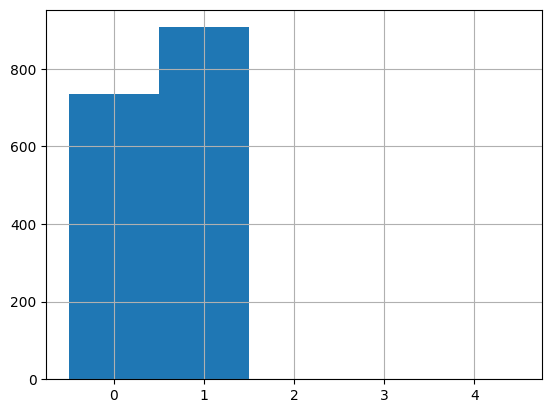

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info


In [6]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\model\fingerprint descriptor model"

# RF
rf_morgan = joblib.load(fr"{base_path}\Model_Oral_toxicity_RF_morgan.pkl")
rf_maccs  = joblib.load(fr"{base_path}\Model_Oral_toxicity_RF_maccskey.pkl")
rf_modred = joblib.load(fr"{base_path}\Model_Oral_toxicity_RF_modred.pkl")

# SVM
svm_morgan = joblib.load(fr"{base_path}\Model_Oral_toxicity_SVM_morgan.pkl")
svm_maccs  = joblib.load(fr"{base_path}\Model_Oral_toxicity_SVM_maccskey.pkl")
svm_modred = joblib.load(fr"{base_path}\Model_Oral_toxicity_SVM_modred.pkl")

# XGB
xgb_morgan = joblib.load(fr"{base_path}\Model_Oral_toxicity_XGB_morgan.pkl")
xgb_maccs  = joblib.load(fr"{base_path}\Model_Oral_toxicity_XGB_maccskey.pkl")
xgb_modred = joblib.load(fr"{base_path}\Model_Oral_toxicity_XGB_modred.pkl")

# NN
nn_morgan = joblib.load(fr"{base_path}\Model_Oral_toxicity_NN_morgan.pkl")
nn_maccs  = joblib.load(fr"{base_path}\Model_Oral_toxicity_NN_maccskey.pkl")
nn_modred = joblib.load(fr"{base_path}\Model_Oral_toxicity_NN_modred.pkl")

# LGBM
lgbm_morgan = joblib.load(fr"{base_path}\Model_Oral_toxicity_LGBM_morgan.pkl")
lgbm_maccs  = joblib.load(fr"{base_path}\Model_Oral_toxicity_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{base_path}\Model_Oral_toxicity_LGBM_modred.pkl")

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [8]:
# Consensus with probability average 

def predict_with_models_probabilities(moldf):
   
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
   # mean_probs = np.mean([morgan_probs, maccs_probs], axis=0)
   # mean_probs = np.mean([maccs_probs, modred_probs], axis=0)
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions

# Run prediction
final_predictions = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions

print(test_df[['SMILES', 'Predictions']])

                                                 SMILES  Predictions
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...            0
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...            0
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1            0
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O            0
859                                   O=C(Cl)OCc1ccccc1            1
...                                                 ...          ...
932                                         CC(Br)C=CCl            1
933                                 CC(C)SSC(Cl)C(Cl)Cl            1
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...            1
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...            1
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1            1

[1643 rows x 2 columns]


In [9]:
#RF average test
def predict_with_models_probabilities(test_df):

    # MORGAN
    morgan_probs = rf_morgan.predict_proba(
        np.array(list(test_df['Morgan_Descriptors'].values))
    )[:, 1]

    # MACCSKEY
    maccs_probs = rf_maccs.predict_proba(
        np.array(list(test_df['MACCS_Descriptors'].values))
    )[:, 1]

    # MODRED
    modred_probs = rf_modred.predict_proba(
        np.array(list(test_df['Modred_Descriptor'].values))
    )[:, 1]

    # CONSENSUS MEAN PROBABILITY
    mean_probs = np.mean(
        [morgan_probs, maccs_probs, modred_probs],
        axis=0
    )

    # FINAL CLASS
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)

test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = test_df['Outcome'].astype(int)

print(test_df[['SMILES', 'Predictions', 'Mean_Probabilities']])


from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)

                                                 SMILES  Predictions  \
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...            0   
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...            0   
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1            0   
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O            0   
859                                   O=C(Cl)OCc1ccccc1            1   
...                                                 ...          ...   
932                                         CC(Br)C=CCl            1   
933                                 CC(C)SSC(Cl)C(Cl)Cl            1   
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...            1   
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...            1   
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1            1   

      Mean_Probabilities  
0               0.175841  
849             0.328154  
852             0.227340  
855             0.297720  


In [10]:
#RF Individual test

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary') 
    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)

# Assuming y_true is defined
morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[518 218]
 [208 699]]
Accuracy: 0.740718198417529
AUC Score: 0.8261124227026508
F1 Score: 0.7664473684210527
Sensitivity: 0.7706725468577729
Specificity: 0.7038043478260869
CCR (Correct Classification Rate): 0.7372384473419299
PPV (Positive Predictive Value): 0.7622682660850599
NPV (Negative Predictive Value): 0.7134986225895317

MACCS Performance:
Confusion Matrix: [[489 247]
 [147 760]]
Accuracy: 0.7601947656725502
AUC Score: 0.8370621314893821
F1 Score: 0.7941483803552769
Sensitivity: 0.8379272326350606
Specificity: 0.6644021739130435
CCR (Correct Classification Rate): 0.751164703274052
PPV (Positive Predictive Value): 0.7547169811320755
NPV (Negative Predictive Value): 0.7688679245283019

Modred Performance:
Confusion Matrix: [[518 218]
 [149 758]]
Accuracy: 0.7766281192939745
AUC Score: 0.862283387661186
F1 Score: 0.8050982474774296
Sensitivity: 0.8357221609702316
Specificity: 0.7038043478260869
CCR (Correct Classification Rate): 0.7697632543

In [11]:
# SVM average test
def predict_with_models_probabilities(test_df):

    # MORGAN
    morgan_probs = svm_morgan.predict_proba(
        np.array(list(test_df['Morgan_Descriptors'].values))
    )[:, 1]

    # MACCSKEY
    maccs_probs = svm_maccs.predict_proba(
        np.array(list(test_df['MACCS_Descriptors'].values))
    )[:, 1]

    # MODRED
    modred_probs = svm_modred.predict_proba(
        np.array(list(test_df['Modred_Descriptor'].values))
    )[:, 1]

    # CONSENSUS MEAN PROBABILITY
    mean_probs = np.mean(
        [morgan_probs, maccs_probs, modred_probs],
        axis=0
    )

    # FINAL CLASS
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)

test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = test_df['Outcome'].astype(int)

print(test_df[['SMILES', 'Predictions', 'Mean_Probabilities']])

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)

                                                 SMILES  Predictions  \
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...            0   
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...            0   
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1            0   
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O            0   
859                                   O=C(Cl)OCc1ccccc1            0   
...                                                 ...          ...   
932                                         CC(Br)C=CCl            1   
933                                 CC(C)SSC(Cl)C(Cl)Cl            1   
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...            1   
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...            1   
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1            1   

      Mean_Probabilities  
0               0.240130  
849             0.385670  
852             0.271136  
855             0.284404  


In [12]:
# SVM Individual test

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = svm_morgan.predict_proba(
        np.array(list(test_df['Morgan_Descriptors'].values))
    )[:, 1]

    maccs_probs = svm_maccs.predict_proba(
        np.array(list(test_df['MACCS_Descriptors'].values))
    )[:, 1]

    modred_probs = svm_modred.predict_proba(
        np.array(list(test_df['Modred_Descriptor'].values))
    )[:, 1]

    # Convert probabilities → class prediction
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)

    return (
        morgan_predictions, morgan_probs,
        maccs_predictions, maccs_probs,
        modred_predictions, modred_probs
    )


def evaluate_performance(y_true, predictions, probabilities):

    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities)
    f1 = f1_score(y_true, predictions, average='binary')

    tn, fp, fn, tp = conf_matrix.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }


# Run prediction
(
    morgan_predictions, morgan_probs,
    maccs_predictions, maccs_probs,
    modred_predictions, modred_probs
) = predict_with_models_probabilities(test_df)


# Evaluation
morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)


# Print result
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")

Morgan Performance:
Confusion Matrix: [[513 223]
 [186 721]]
Accuracy: 0.751065124771759
AUC Score: 0.8232002900148604
F1 Score: 0.7790383576445165
Sensitivity: 0.794928335170893
Specificity: 0.6970108695652174
CCR (Correct Classification Rate): 0.7459696023680552
PPV (Positive Predictive Value): 0.763771186440678
NPV (Negative Predictive Value): 0.7339055793991416

MACCS Performance:
Confusion Matrix: [[502 234]
 [163 744]]
Accuracy: 0.7583688374923919
AUC Score: 0.8395263589952544
F1 Score: 0.7893899204244031
Sensitivity: 0.8202866593164277
Specificity: 0.6820652173913043
CCR (Correct Classification Rate): 0.7511759383538661
PPV (Positive Predictive Value): 0.7607361963190185
NPV (Negative Predictive Value): 0.7548872180451128

Modred Performance:
Confusion Matrix: [[541 195]
 [188 719]]
Accuracy: 0.7668898356664637
AUC Score: 0.8432331863285556
F1 Score: 0.7896760021965953
Sensitivity: 0.7927232635060639
Specificity: 0.7350543478260869
CCR (Correct Classification Rate): 0.7638888056

In [14]:
# XGB average test
def predict_with_models_probabilities(test_df):

    # MORGAN
    morgan_probs = xgb_morgan.predict_proba(
        np.array(list(test_df['Morgan_Descriptors'].values))
    )[:, 1]

    # MACCSKEY
    maccs_probs = xgb_maccs.predict_proba(
        np.array(list(test_df['MACCS_Descriptors'].values))
    )[:, 1]

    # MODRED
    modred_probs = xgb_modred.predict_proba(
        np.array(list(test_df['Modred_Descriptor'].values))
    )[:, 1]

    # CONSENSUS MEAN PROBABILITY
    mean_probs = np.mean(
        [morgan_probs, maccs_probs, modred_probs],
        axis=0
    )

    # FINAL CLASS
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)

test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = test_df['Outcome'].astype(int)

print(test_df[['SMILES', 'Predictions', 'Mean_Probabilities']])

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)


                                                 SMILES  Predictions  \
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...            0   
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...            0   
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1            0   
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O            0   
859                                   O=C(Cl)OCc1ccccc1            1   
...                                                 ...          ...   
932                                         CC(Br)C=CCl            1   
933                                 CC(C)SSC(Cl)C(Cl)Cl            1   
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...            1   
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...            0   
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1            1   

      Mean_Probabilities  
0               0.310672  
849             0.306976  
852             0.153901  
855             0.179119  


In [13]:
#XGB Individual test

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
def predict_with_models_probabilities(test_df):

    morgan_probs = xgb_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = xgb_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = xgb_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_pexgbormance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary') 
    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)

# Assuming y_true is defined
morgan_pexgbormance = evaluate_pexgbormance(y_true, morgan_predictions, morgan_probs)
maccs_pexgbormance = evaluate_pexgbormance(y_true, maccs_predictions, maccs_probs)
modred_pexgbormance = evaluate_pexgbormance(y_true, modred_predictions, modred_probs)

# Print pexgbormance for each model
print("Morgan Pexgbormance:")
for metric, value in morgan_pexgbormance.items():
    print(f"{metric}: {value}")

print("\nMACCS Pexgbormance:")
for metric, value in maccs_pexgbormance.items():
    print(f"{metric}: {value}")

print("\nModred Pexgbormance:")
for metric, value in modred_pexgbormance.items():
    print(f"{metric}: {value}")


Morgan Pexgbormance:
Confusion Matrix: [[499 237]
 [192 715]]
Accuracy: 0.7388922702373707
AUC Score: 0.8152338694214084
F1 Score: 0.7692307692307693
Sensitivity: 0.7883131201764058
Specificity: 0.6779891304347826
CCR (Correct Classification Rate): 0.7331511253055942
PPV (Positive Predictive Value): 0.7510504201680672
NPV (Negative Predictive Value): 0.7221418234442837

MACCS Pexgbormance:
Confusion Matrix: [[506 230]
 [165 742]]
Accuracy: 0.7595861229458308
AUC Score: 0.8413187287282489
F1 Score: 0.7897817988291644
Sensitivity: 0.8180815876515987
Specificity: 0.6875
CCR (Correct Classification Rate): 0.7527907938257994
PPV (Positive Predictive Value): 0.7633744855967078
NPV (Negative Predictive Value): 0.7540983606557377

Modred Pexgbormance:
Confusion Matrix: [[525 211]
 [174 733]]
Accuracy: 0.7656725502130249
AUC Score: 0.8494439384497388
F1 Score: 0.7920043219881145
Sensitivity: 0.8081587651598677
Specificity: 0.7133152173913043
CCR (Correct Classification Rate): 0.760736991275586


In [15]:
# NN average test
def predict_with_models_probabilities(test_df):

    # MORGAN
    morgan_probs = nn_morgan.predict_proba(
        np.array(list(test_df['Morgan_Descriptors'].values))
    )[:, 1]

    # MACCSKEY
    maccs_probs = nn_maccs.predict_proba(
        np.array(list(test_df['MACCS_Descriptors'].values))
    )[:, 1]

    # MODRED
    modred_probs = nn_modred.predict_proba(
        np.array(list(test_df['Modred_Descriptor'].values))
    )[:, 1]

    # CONSENSUS MEAN PROBABILITY
    mean_probs = np.mean(
        [morgan_probs, maccs_probs, modred_probs],
        axis=0
    )

    # FINAL CLASS
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)

test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = test_df['Outcome'].astype(int)

print(test_df[['SMILES', 'Predictions', 'Mean_Probabilities']])

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)


                                                 SMILES  Predictions  \
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...            1   
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...            1   
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1            0   
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O            0   
859                                   O=C(Cl)OCc1ccccc1            1   
...                                                 ...          ...   
932                                         CC(Br)C=CCl            1   
933                                 CC(C)SSC(Cl)C(Cl)Cl            1   
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...            1   
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...            1   
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1            1   

      Mean_Probabilities  
0               0.527956  
849             0.569119  
852             0.183989  
855             0.209408  


In [16]:
#NN Individual test

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
def predict_with_models_probabilities(test_df):

    morgan_probs = nn_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = nn_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = nn_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_pennormance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary') 
    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)

# Assuming y_true is defined
morgan_pennormance = evaluate_pennormance(y_true, morgan_predictions, morgan_probs)
maccs_pennormance = evaluate_pennormance(y_true, maccs_predictions, maccs_probs)
modred_pennormance = evaluate_pennormance(y_true, modred_predictions, modred_probs)

# Print pennormance for each model
print("Morgan Pennormance:")
for metric, value in morgan_pennormance.items():
    print(f"{metric}: {value}")

print("\nMACCS Pennormance:")
for metric, value in maccs_pennormance.items():
    print(f"{metric}: {value}")

print("\nModred Pennormance:")
for metric, value in modred_pennormance.items():
    print(f"{metric}: {value}")


Morgan Pennormance:
Confusion Matrix: [[506 230]
 [203 704]]
Accuracy: 0.736457699330493
AUC Score: 0.8030483018551363
F1 Score: 0.7648017381857686
Sensitivity: 0.7761852260198456
Specificity: 0.6875
CCR (Correct Classification Rate): 0.7318426130099228
PPV (Positive Predictive Value): 0.7537473233404711
NPV (Negative Predictive Value): 0.7136812411847673

MACCS Pennormance:
Confusion Matrix: [[474 262]
 [166 741]]
Accuracy: 0.73950091296409
AUC Score: 0.8014401874310917
F1 Score: 0.7759162303664922
Sensitivity: 0.8169790518191842
Specificity: 0.6440217391304348
CCR (Correct Classification Rate): 0.7305003954748095
PPV (Positive Predictive Value): 0.7387836490528414
NPV (Negative Predictive Value): 0.740625

Modred Pennormance:
Confusion Matrix: [[ 38 698]
 [ 71 836]]
Accuracy: 0.5319537431527693
AUC Score: 0.4350582426537558
F1 Score: 0.6849651782056534
Sensitivity: 0.9217199558985667
Specificity: 0.051630434782608696
CCR (Correct Classification Rate): 0.4866751953405877
PPV (Positive

In [17]:
# LGBM average test
def predict_with_models_probabilities(test_df):

    # MORGAN
    morgan_probs = lgbm_morgan.predict_proba(
        np.array(list(test_df['Morgan_Descriptors'].values))
    )[:, 1]

    # MACCSKEY
    maccs_probs = lgbm_maccs.predict_proba(
        np.array(list(test_df['MACCS_Descriptors'].values))
    )[:, 1]

    # MODRED
    modred_probs = lgbm_modred.predict_proba(
        np.array(list(test_df['Modred_Descriptor'].values))
    )[:, 1]

    # CONSENSUS MEAN PROBABILITY
    mean_probs = np.mean(
        [morgan_probs, maccs_probs, modred_probs],
        axis=0
    )

    # FINAL CLASS
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)

test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = test_df['Outcome'].astype(int)

print(test_df[['SMILES', 'Predictions', 'Mean_Probabilities']])

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)


                                                 SMILES  Predictions  \
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...            0   
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...            0   
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1            0   
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O            0   
859                                   O=C(Cl)OCc1ccccc1            1   
...                                                 ...          ...   
932                                         CC(Br)C=CCl            1   
933                                 CC(C)SSC(Cl)C(Cl)Cl            1   
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...            1   
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...            0   
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1            1   

      Mean_Probabilities  
0               0.166417  
849             0.311972  
852             0.174669  
855             0.219983  


In [18]:
#LGBM Individual test

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
def predict_with_models_probabilities(test_df):

    morgan_probs = lgbm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = lgbm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = lgbm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_pelgbmormance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary') 
    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)

# Assuming y_true is defined
morgan_pelgbmormance = evaluate_pelgbmormance(y_true, morgan_predictions, morgan_probs)
maccs_pelgbmormance = evaluate_pelgbmormance(y_true, maccs_predictions, maccs_probs)
modred_pelgbmormance = evaluate_pelgbmormance(y_true, modred_predictions, modred_probs)

# Print pelgbmormance for each model
print("Morgan Pelgbmormance:")
for metric, value in morgan_pelgbmormance.items():
    print(f"{metric}: {value}")

print("\nMACCS Pelgbmormance:")
for metric, value in maccs_pelgbmormance.items():
    print(f"{metric}: {value}")

print("\nModred Pelgbmormance:")
for metric, value in modred_pelgbmormance.items():
    print(f"{metric}: {value}")


Morgan Pelgbmormance:
Confusion Matrix: [[554 182]
 [234 673]]
Accuracy: 0.7468046256847231
AUC Score: 0.8265228776185226
F1 Score: 0.7639046538024972
Sensitivity: 0.7420066152149944
Specificity: 0.7527173913043478
CCR (Correct Classification Rate): 0.7473620032596711
PPV (Positive Predictive Value): 0.7871345029239766
NPV (Negative Predictive Value): 0.7030456852791879

MACCS Pelgbmormance:
Confusion Matrix: [[544 192]
 [195 712]]
Accuracy: 0.7644552647595861
AUC Score: 0.8401547744595177
F1 Score: 0.7863059083379348
Sensitivity: 0.7850055126791621
Specificity: 0.7391304347826086
CCR (Correct Classification Rate): 0.7620679737308853
PPV (Positive Predictive Value): 0.7876106194690266
NPV (Negative Predictive Value): 0.7361299052774019

Modred Pelgbmormance:
Confusion Matrix: [[510 226]
 [193 714]]
Accuracy: 0.7449786975045648
AUC Score: 0.8356577465126311
F1 Score: 0.7731456415809421
Sensitivity: 0.7872105843439912
Specificity: 0.6929347826086957
CCR (Correct Classification Rate): 0.7

In [20]:
# ===============================
# LGBM CONSENSUS ONLY
# Morgan LGBM + Modred LGBM
# ===============================

def lgbm_consensus(test_df):

    # LGBM Morgan probability
    lgbm_morgan_prob = lgbm_morgan.predict_proba(
        np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]

    # LGBM Modred probability
    lgbm_modred_prob = lgbm_modred.predict_proba(
        np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]

    # Average probability (LGBM consensus)
    lgbm_mean_prob = (lgbm_morgan_prob + lgbm_modred_prob) / 2

    # Final LGBM prediction
    lgbm_prediction = (lgbm_mean_prob > 0.5).astype(int)

    return lgbm_prediction, lgbm_mean_prob


# RUN LGBM CONSENSUS
lgbm_pred, lgbm_prob = lgbm_consensus(test_df)

test_df['LGBM_Prediction'] = lgbm_pred
test_df['LGBM_Probability'] = lgbm_prob

print(test_df[['SMILES', 'LGBM_Prediction', 'LGBM_Probability']])


# ===============================
# EVALUATION
# ===============================

from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

y_true = test_df['Outcome'].astype(int)

conf_matrix = confusion_matrix(y_true, lgbm_pred)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, lgbm_pred)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, lgbm_prob)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, lgbm_pred)
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR:", ccr)

ppv = tp / (tp + fp)
print("PPV:", ppv)

npv = tn / (tn + fn)
print("NPV:", npv)

                                                 SMILES  LGBM_Prediction  \
0     O=C(Nc1ccccc1C(=O)O)C(=Cc1ccccc1)C(=O)Nc1ccccc...                0   
849   CC(C)(C)c1cc2c(c(C(C)(C)C)c1)OP(=O)(O)Oc1c(cc(...                0   
852                       COCCCOCC(C)OCCCOC(=O)c1ccccc1                0   
855                  CCC12CCC3c4ccc(O)cc4CCC3C1CC(O)C2O                0   
859                                   O=C(Cl)OCc1ccccc1                1   
...                                                 ...              ...   
932                                         CC(Br)C=CCl                1   
933                                 CC(C)SSC(Cl)C(Cl)Cl                1   
934   COc1ccc2c(c1)c(CC(=O)OCOC(=O)c1ccccc1)c(C)n2C(...                1   
920   COC(=O)C1=C(C#N)NC(C)=C(C(=O)OC(C)C)C1c1cccc([...                0   
1642                  CC(C)NC(=O)N1CCc2nc(N=C(N)N)sc2C1                1   

      LGBM_Probability  
0             0.223988  
849           0.409219  
852         